In [1]:
import numpy as np
import scanpy as sc
import anndata as an
import pandas as pd

## Import Data

Using as of 3/20/2025 
Gene threshold set to: 0.002
Random state: 1
10x tags removed

In [ ]:
data=an.read_h5ad("/home/nicoleb/Cytokine_Pf2_NB30_noreg.h5ad")

/home/nicoleb/Pf2-scRNAseq-1/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [3]:

types = {
		'Monocytes' : [
			'CD14',
			'CD33',
			'LYZ',
			'FCER1G',
			'LGALS3',
			'CSF1R',
			'ITGAX',
			'ITGAM',
			'CD86',
			'HLA-DRB1'],
		'Dendritic cells' : [
			'LAD1',
			'LAMP3',
			'TSPAN13',
			'CLIC2',
			'FLT3'],
		'B-cells' : [
			'MS4A1',
			'CD19',
			'CD79A',
            'RALGPS2'],
		
		'T cells' : [
			'CD27',
			'CD69',
			'CD2',
            'CD4',
            'CD8A',
            'CD8B',
			'CD3D',
			'CXCR3',
			'CCL5',
			'IL7R',
			'CXCL8',
			'GZMK'],
		'Natural Killers' : [
			'NKG7',
			'GNLY',
			'PRF1',
			'FCGR3A',
			'NCAM1',
			'TYROBP']
	}


In [3]:
print(data)
sc.pp.highly_variable_genes(data, min_mean=0.0005, max_mean=10, min_disp=0.5)
adata = data[:, data.var.highly_variable]
print(adata)

AnnData object with n_obs × n_vars = 19747 × 18596
    obs: 'Condition', 'condition_unique_idxs'
    var: 'ENSEMBLE_ids', 'feature_type', 'means'
    uns: 'Pf2_A', 'Pf2_B', 'Pf2_weights'
    obsm: 'X_pf2_PaCMAP', 'projections', 'weighted_projections'
    varm: 'Pf2_C'
View of AnnData object with n_obs × n_vars = 19747 × 6592
    obs: 'Condition', 'condition_unique_idxs'
    var: 'ENSEMBLE_ids', 'feature_type', 'means', 'highly_variable', 'dispersions', 'dispersions_norm'
    uns: 'Pf2_A', 'Pf2_B', 'Pf2_weights', 'hvg'
    obsm: 'X_pf2_PaCMAP', 'projections', 'weighted_projections'
    varm: 'Pf2_C'


/home/nicoleb/Pf2-scRNAseq-1/.venv/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding


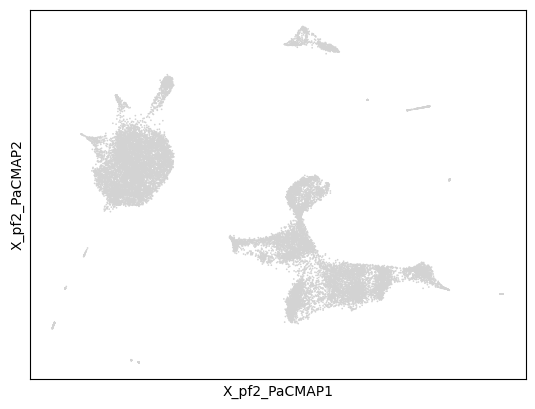

In [21]:
sc.pl.embedding(basis="X_pf2_PaCMAP", adata=data)

/tmp/ipykernel_95269/2220746436.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, random_state=0, resolution=0.5)


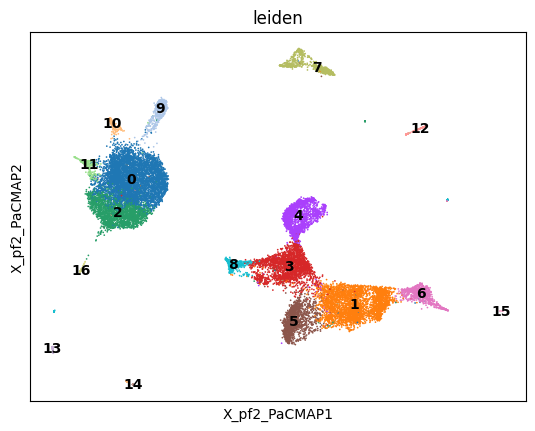

In [5]:
sc.pp.neighbors(adata, use_rep="projections", random_state=0)
sc.tl.leiden(adata, random_state=0, resolution=0.5)
sc.pl.embedding(basis="X_pf2_PaCMAP", adata=adata, color=["leiden"], legend_loc='on data') #basis of cell embedding  use projections form pf2
#tell model how many groupings of interconncected cells you want 
#resolution creates groups, higher more clusters 

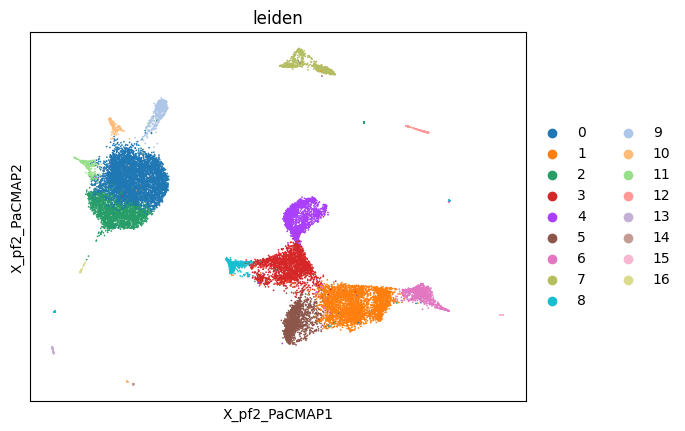

In [21]:
sc.pl.embedding(basis="X_pf2_PaCMAP", adata=adata, color=["leiden"]) #basis of cell embedding  use projections form pf2

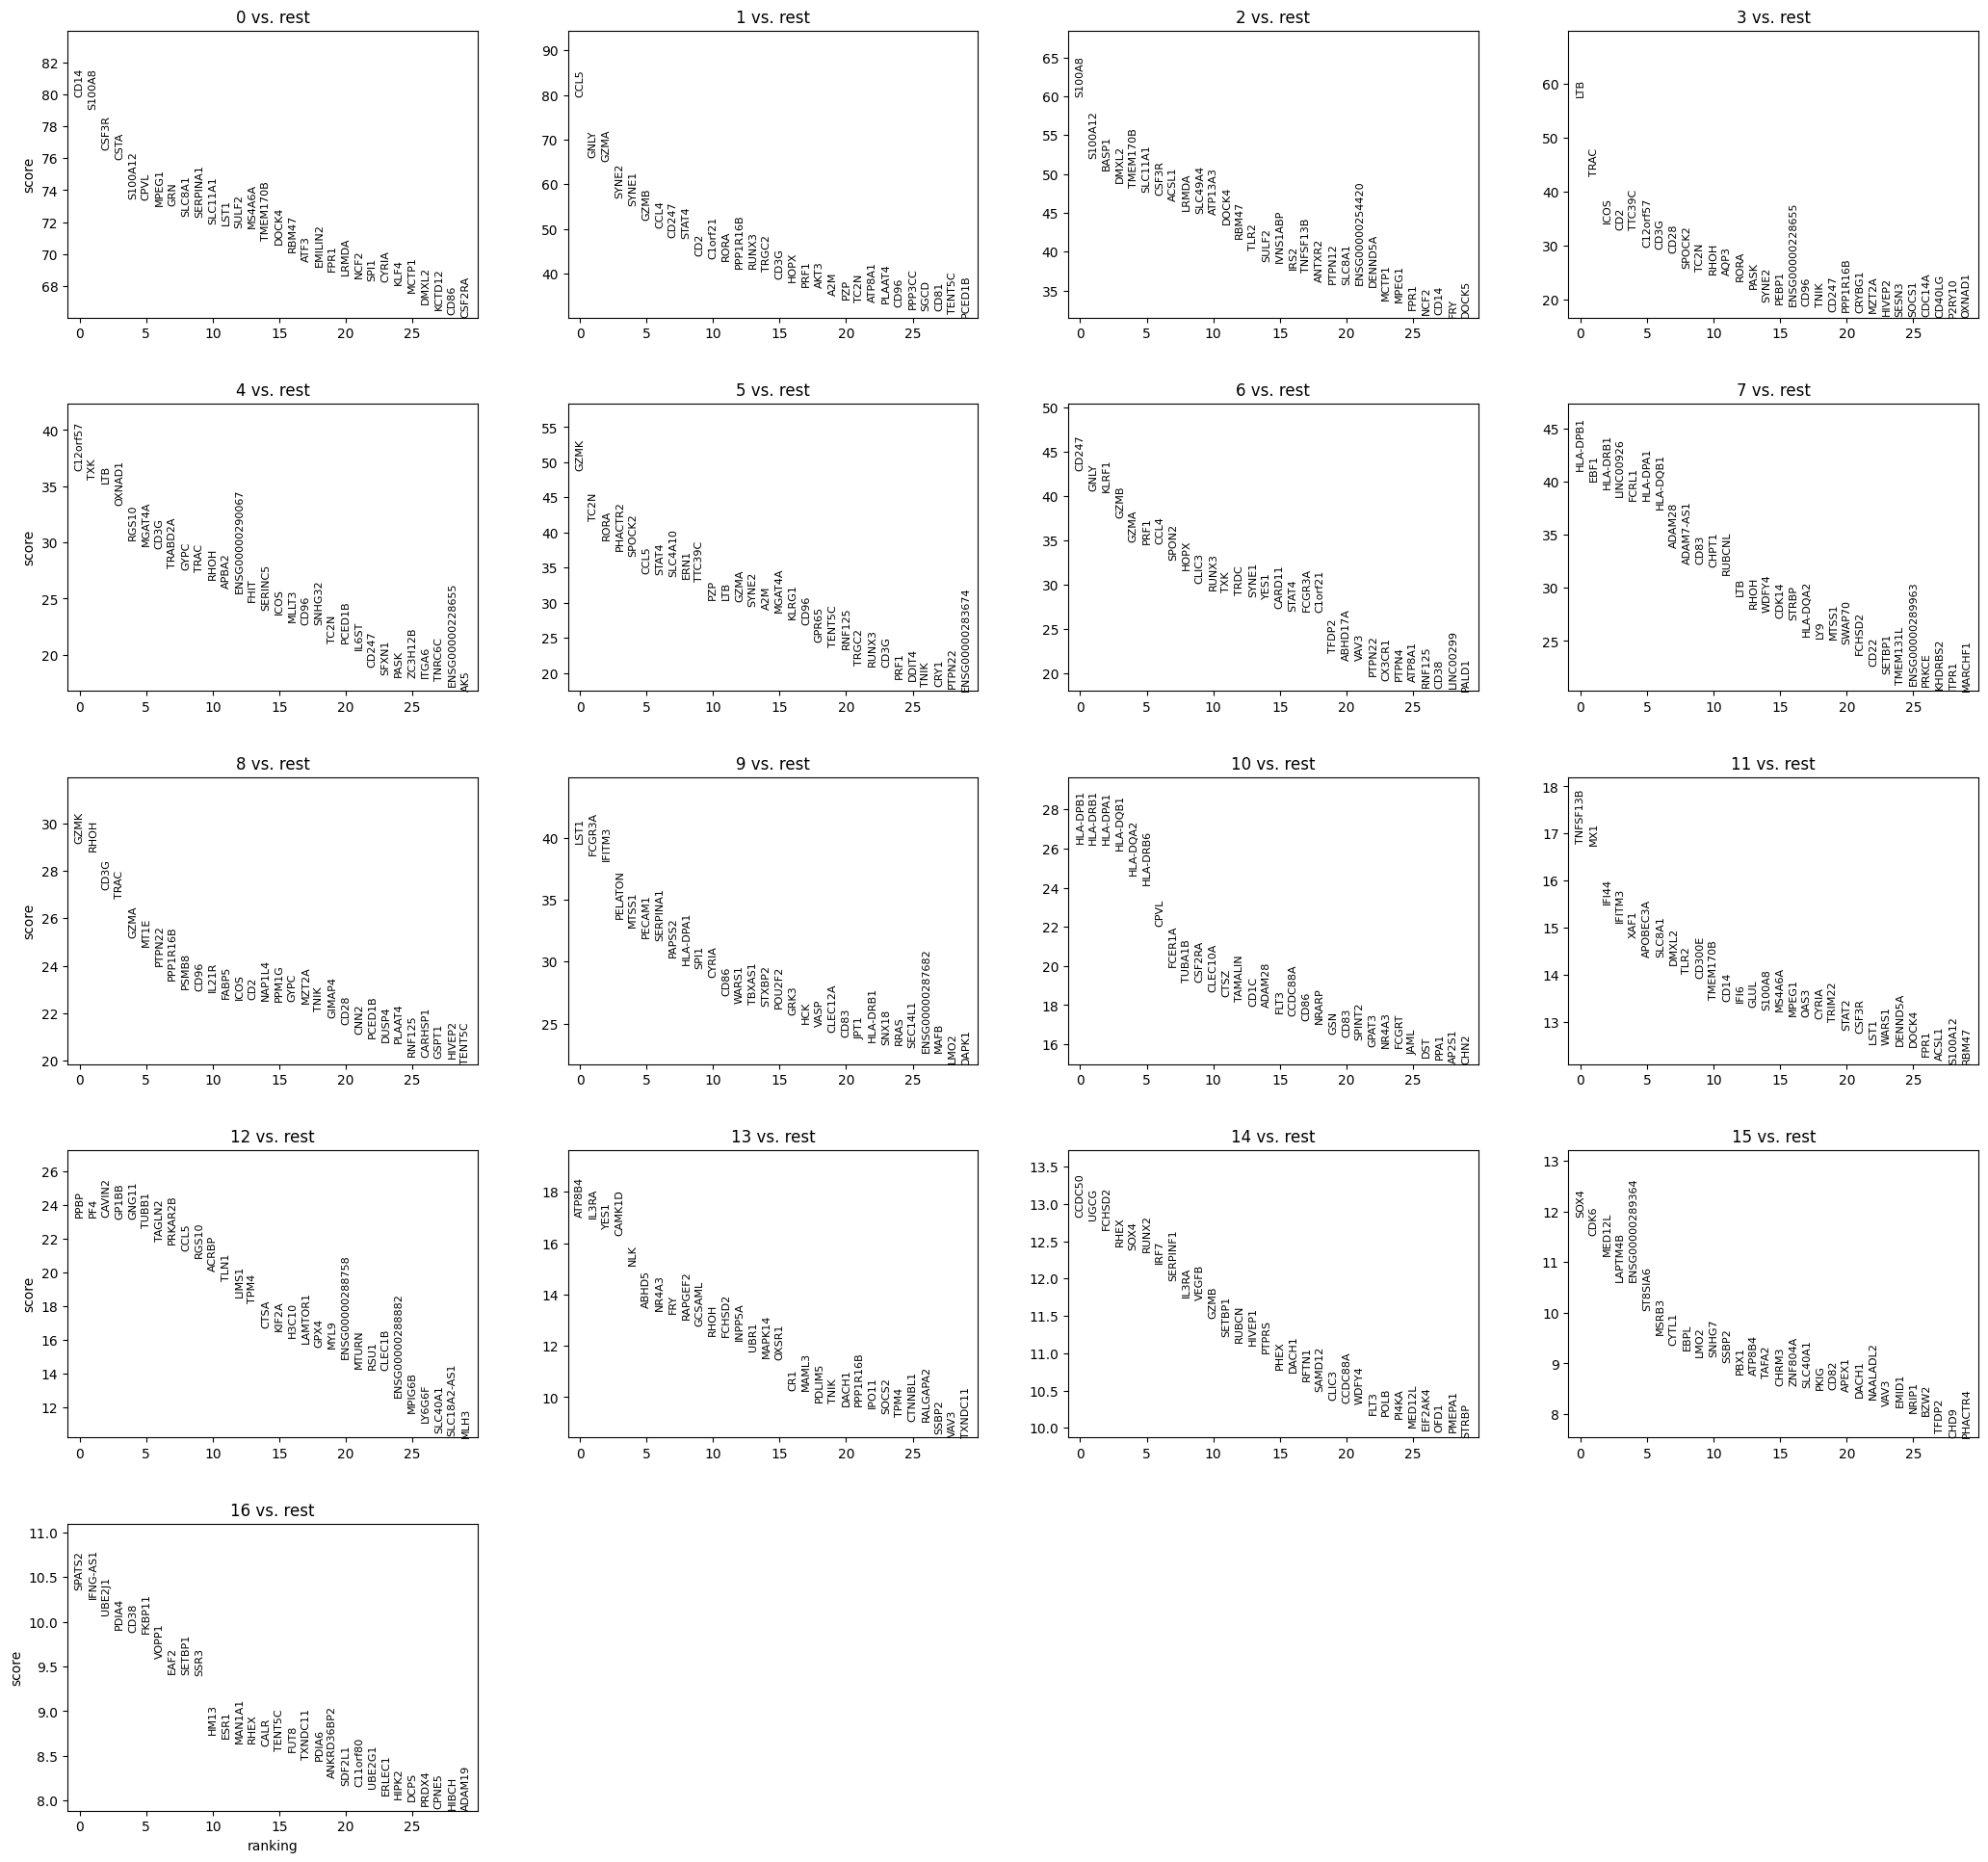

In [22]:
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon')
sc.pl.rank_genes_groups(adata, n_genes=30, sharey=False, save=True)

In [7]:
cellDF = sc.tl.marker_gene_overlap(adata, types)
with pd.option_context('display.max_rows', None,
                       'display.max_columns', None,
                       'display.precision', 3,
                       ):
    print(cellDF)

ValueError: Could not find marker gene data. Please run `sc.tl.rank_genes_groups()` first.

In [6]:
sc.pp.neighbors(data, use_rep="projections")
sc.tl.leiden(data)

In [7]:
celltypedict_layer1 = {"0": "Monocytes",
                       "1": "T cells",
                       "2": "Monocytes", 
                       "3": "T cells", 
                       "4": "T cells",
                       "5": "T cells",
                       "6": "NK cells", 
                       "7": "Monocytes",
                       "8": "T cells", 
                       "9": "Monocytes",
                       "10": "Monocytes", 
                       "11": "Monocytes",
                       "12": "T cells",
                       "13" : "Basophil",
                       "14" : "pDC",
                       "15" : "NA",
                       "16" : "Plasma cells"
                       
                       
                       
                       }

print(adata.obs.leiden.replace(celltypedict_layer1))
adata.obs["CellType1"] = adata.obs.leiden.replace(celltypedict_layer1)

AAACCCACAAGACAAT-1      T cells
AAACCCACACTGATTG-1    Monocytes
AAACGAAAGGACAGTC-1    Monocytes
AAACGCTAGGATATGT-1    Monocytes
AAACGCTCAGGTAGTG-1      T cells
                        ...    
TTTGGAGGTGACTAAA-1      T cells
TTTGGTTAGTGGCGAT-1    Monocytes
TTTGGTTTCGACGACC-1      T cells
TTTGGTTTCGTAGCCG-1    Monocytes
TTTGTTGAGGATTCAA-1    Monocytes
Name: leiden, Length: 19747, dtype: category
Categories (7, object): ['Monocytes', 'T cells', 'NK cells', 'Basophil', 'pDC', 'NA', 'Plasma cells']


/tmp/ipykernel_2279965/988288946.py:23: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  print(adata.obs.leiden.replace(celltypedict_layer1))
/tmp/ipykernel_2279965/988288946.py:24: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs["CellType1"] = adata.obs.leiden.replace(celltypedict_layer1)


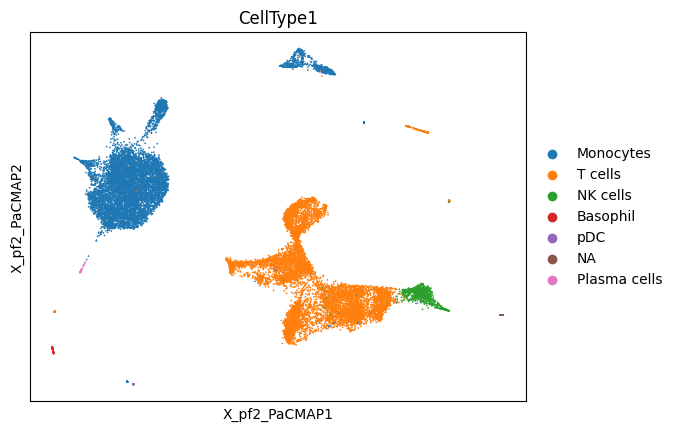

In [10]:
sc.pl.embedding(basis="X_pf2_PaCMAP", adata=adata, color=["CellType1"])

Higher Resolution Leiden

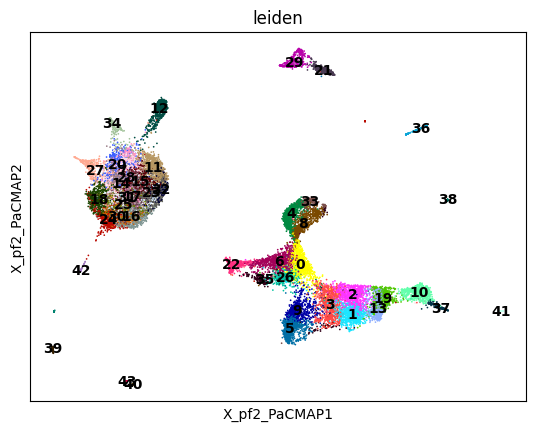

In [6]:
sc.tl.leiden(adata, random_state=0, resolution=3.0)
sc.pl.embedding(basis="X_pf2_PaCMAP", adata=adata, color=["leiden"], legend_loc='on data') #basis of cell embedding  use projections form pf2

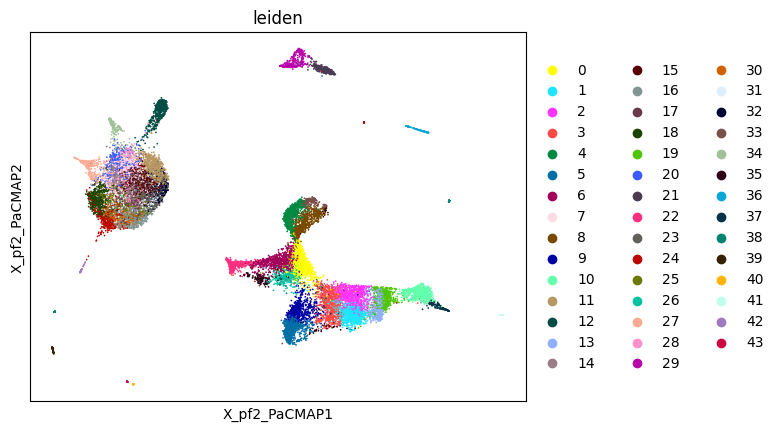

In [9]:
sc.pl.embedding(basis="X_pf2_PaCMAP", adata=adata, color=["leiden"]) #basis of cell embedding  use projections form pf2

/home/nicoleb/Pf2-scRNAseq-1/.venv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:429: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/home/nicoleb/Pf2-scRNAseq-1/.venv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:431: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/home/nicoleb/Pf2-scRNAseq-1/.venv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:434: Perform

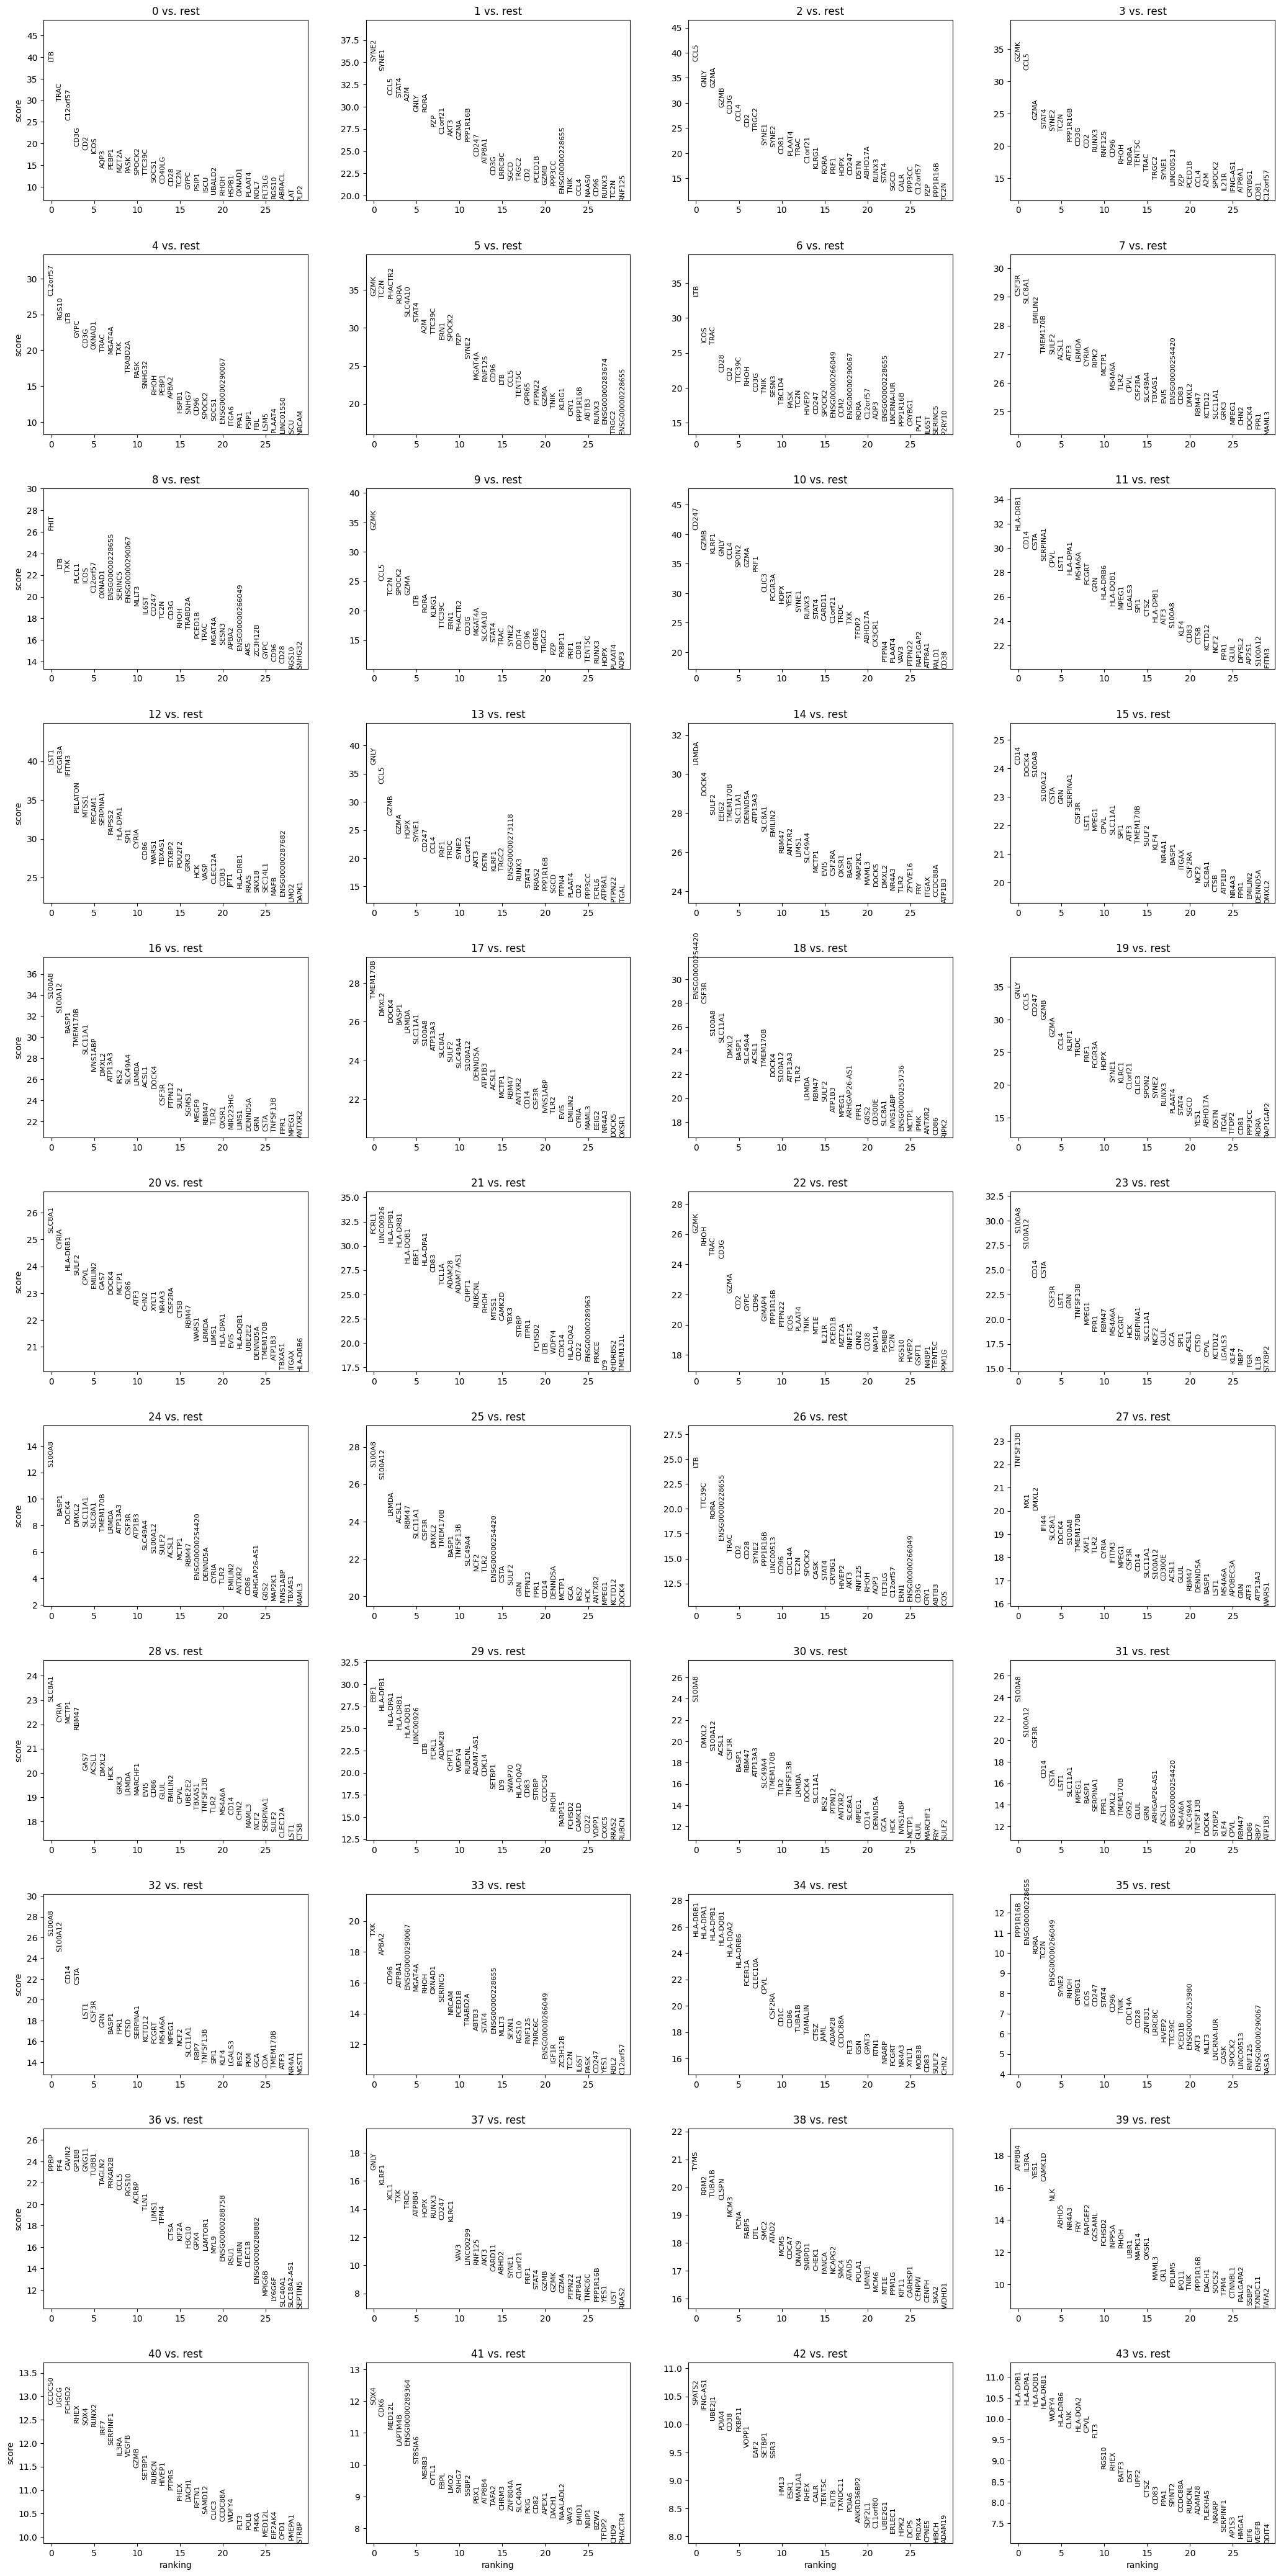

In [10]:
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon')
sc.pl.rank_genes_groups(adata, n_genes=30, sharey=False, save=True)

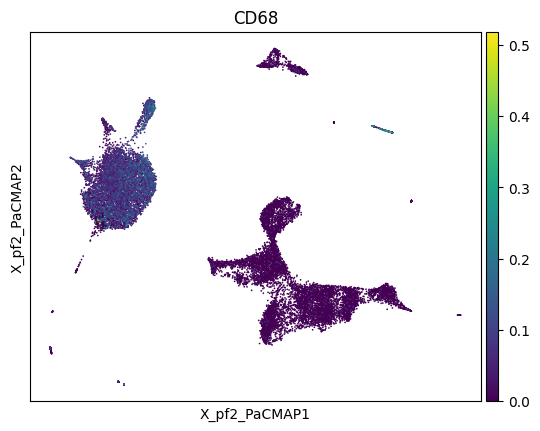

In [34]:
sc.pl.embedding(data, basis="X_pf2_PaCMAP", color=["CD68"])

In [47]:
types2 = {
		'B cells' : [
			'PXK',
			'MS4A1',
			'CD19',
			'CD74',
			'CD79A',
			'BANK1',
			'PTPRC',
			'CR2'],
        'B Memory' : ["NPIB15",
                      "BACH2",
                      "IL7",
                      "NMBR",
                      "MS4A1",
                      "MBL2",
                      "LY86"],
        'B Naive' : ["P2RX5",
                      "SIK1",
                      "SLC12A1",
                      "SELL",
                      "RALGPS2",
                      "PTPRCAP",
                      "PSG2"],
        'Basophils' : ["CCL4",
                      "NPL",
                      "WRN",
                      "NFIL3",
                      "TEC",
                      "OTUB2",
                      "FAR2"],
        'DCs' : ["ITGAX",
                      "ZBTB46",
                      "LAMP3",
                      "CXCR1",
                      "ITGAM",
                      "FCER1A",
                      "IL6"],
        'Eosinophils' : ["CSF2",
                      "EPX",
                      "SIGLEC8",
                      "CCL5",
                      "IKZF2",
                      "CPA3",
                      "PRPG2"],
        'Gamma T Cells' : ["S100B",
                      "TUBB",
                      "TRGJP2",
                      "STMN1",
                      "TRGV9",
                      "CCL5",
                      "HMGB2"],
	    'Macrophages' : ["CD68",
                      "FCGR1",
                      "NAAA",
                      "JAML",
                      "TYROBP",
                      "LYZ2",
                      "H2-DMA"],
	    'Mast Cells' : ["SLC29A1",
                      "KIT",
                      "LTC4S",
                      "TPSAB1",
                      "IL1RL1",
                      "HDC",
                      "TPSB2"],
	    'Megakaryocytes' : ["PLK3",
                      "PROX1",
                      "SYP",
                      "TSPAN9",
                      "RGS18",
                      "GATA2",
                      "VWF"],
        'Monocytes' : ["APOBEC3A",
                      "LYZ",
                      "CD14",
                      "CFP",
                      "HLA-DRA",
                      "S100A9",
                      "S100A8",
                      "CSF3R"],
		'Myeloid Suppressors' : ["S100A4",
                      "S100A9",
                      "ICAM1",
                      "S100A8",
                      "ITGAM",
                      "LY6G",
                      "GR1"],
	    'NKT' : ["IL12RB2",
                      "NCAM1",
                      "GATA3",
                      "CD44",
                      "IL2RB",
                      "CXCR4",
                      "SLAMF7"],
	    'Neutrophils' : ["CSF3R",
                      "LY6G",
                      "S100A8",
                      "TREM1",
                      "IL1R2",
                      "CFP",
                      "ADAM8"],
	    'NK' : ["NKG7",
                      "GNLY",
                      "KLRD1",
                      "KLRF1",
                      "NCR1",
                      "DOCK2",
                      "GZMA"],
	    'Nuocytes' : ["IL1RL1",
                      "ICOS",
                      "IL17RB",
                      "IL7R",
                      "CRLF2",
                      "ARG1",
                      "GATA3"],
    	'Plasma Cells' : ["MZB1",
                      "IGHG1",
                      "SPAG4",
                      "TGM5",
                      "SIK1",
                      "RPL3P7",
                      "RGS13"],
        'Plasmacytoid DCs' : ["BST2",
                      "CLEC4C",
                      "MAP3K2",
                      "KLK1",
                      "CMAH",
                      "TRADD",
                      "LILRA4"],
        'T Cells' : ["TRBC2",
                      "CD3D",
                      "CD3G",
                      "CD3E",
                      "LTB",
                      "IL7R",
                      "LEF1"],
        'Cytotoxic T' : ["TRAC",
                      "CD8A",
                      "GZMB",
                      "CD2",
                      "CD27",
                      "CD5"
                      ],
        'Follicular T' : ["ICOS",
                      "PDCD1",
                      "BCL6",
                      "CXCR5",
                      "CD200",
                      "P2RX7",
                      "CD3D"],
        'Helper T' : ["CCR4",
                      "CD4",
                      "IL13",
                      "CD28",
                      "CD3G",
                      "IL2",
                      "CCR6"],
        'Memory T' : ["CCR7",
                      "CD2",
                      "PTPRC",
                      "CD28",
                      "LEF1",
                      "S100A8",
                      "GIMAP4"],
        'T Reg' : ["IKZF2",
                      "FOXP3",
                      "CCR4",
                      "ENTPD1",
                      "IL2RA",
                      "ITGAE",
                      "TIGIT",
                      "IL10RA",
                      "TNFRSF4",
                      "CTLA4"],
	}

In [45]:
types2 = {
		'B cells' : [
			'PXK',
			'MS4A1',
			'CD19',
			'CD74',
			'CD79A',
			'BANK1',
			'PTPRC',
			'CR2'],
        'B Memory' : ["NPIB15",
                      "BACH2",
                      "IL7",
                      "NMBR",
                      "MS4A1",
                      "MBL2",
                      "LY86"],
        'B Naive' : ["P2RX5",
                      "SIK1",
                      "SLC12A1",
                      "SELL",
                      "RALGPS2",
                      "PTPRCAP",
                      "PSG2"],
       
        'DCs' : ["ITGAX",
                      "ZBTB46",
                      "LAMP3",
                      "CXCR1",
                      "ITGAM",
                      "FCER1A",
                      "IL6"],
       
        'Gamma T Cells' : ["S100B",
                      "TUBB",
                      "TRGJP2",
                      "STMN1",
                      "TRGV9",
                      "CCL5",
                      "HMGB2"],
	    'Macrophages' : ["CD68",
                      "FCGR1",
                      "NAAA",
                      "JAML",
                      "TYROBP",
                      "LYZ2",
                      "H2-DMA"],
	    'CM' : ['CD14'
          'LYZ',
          'S100A8',
          'S100A9',
          'IL8'],
	    'cDC1' : ['LGALGS2',
            'MS4A6A'],
	    'cDC2' : ['HLA-DQA1',
            'HLA-DQA2',
            'HLA-DMB'],
	    'nCM' : ['FCGR3A'],
	    'pDC' : ['SERPINF1',
           'LILRA',
           'IRF8'],
	    
        'Monocytes' : ["APOBEC3A",
                      "LYZ",
                      "CD14",
                      "CFP",
                      "HLA-DRA",
                      "S100A9",
                      "S100A8",
                      "CSF3R"],
		'Myeloid Suppressors' : ["S100A4",
                      "S100A9",
                      "ICAM1",
                      "S100A8",
                      "ITGAM",
                      "LY6G",
                      "GR1"],
	    'NKT' : ["IL12RB2",
                      "NCAM1",
                      "GATA3",
                      "CD44",
                      "IL2RB",
                      "CXCR4",
                      "SLAMF7"],
	    'Neutrophils' : ["CSF3R",
                      "LY6G",
                      "S100A8",
                      "TREM1",
                      "IL1R2",
                      "CFP",
                      "ADAM8"],
	    'NK' : ["NKG7",
                      "GNLY",
                      "KLRD1",
                      "KLRF1",
                      "NCR1",
                      "DOCK2",
                      "GZMA"],
	    
    	'Plasma Cells' : ["MZB1",
                      "IGHG1",
                      "SPAG4",
                      "TGM5",
                      "SIK1",
                      "RPL3P7",
                      "RGS13"],
        'Plasmacytoid DCs' : ["BST2",
                      "CLEC4C",
                      "MAP3K2",
                      "KLK1",
                      "CMAH",
                      "TRADD",
                      "LILRA4"],
        'T Cells' : ["TRBC2",
                      "CD3D",
                      "CD3G",
                      "CD3E",
                      "LTB",
                      "IL7R",
                      "LEF1"],
        'CD8 T' : ["TRAC",
                      "CD8A",
                      "GZMB",
                      "CD2",
                      "CD27",
                      "CD5",
                      "CD27"],
        'CD8 T CEM' : ["TCF7",
                      "CD8A",
                      "GZMK",
                      "PDCD1"
                      ],
        'Follicular T' : ["ICOS",
                      "PDCD1",
                      "BCL6",
                      "CXCR5",
                      "CD200",
                      "P2RX7",
                      "CD3D"],
        'CD4 T' : ["CCR4",
                      "CD4",
                      "IL13",
                      "CD28",
                      "CD3G",
                      "IL2",
                      "CCR6"],
         'CD4 T naive' : ["CCR7",
                     
                      "TCD7",
                      "CD27"
                      "SELL",
                      "CXCR4"],
                      
                     
          'Th1' : ["CXCR6",
                      "TCF7",
                      "IL12RB1",
                      "IL12RB2",
                      "IFNGR1",
                      "IFNGR2",
                      "CXCR3",
                      "TBX21",
                      "STAT4",
                      "STAT1",
                      "IFNG"],
        'Th2' : ["CCR4",
                      "IL14R",
                      "IL17RB",
                      "PTGDR2",
                      "GATA3",
                      "STAT6",
                      "MAF",
                      "IL10"],
        'Th17' : ["CCR6",
                      "IL23R",
                      "IL1R1",
                      "IL1RAP",
                      "RORA",
                      "RORC",
                      "STAT3"],
        'T Reg' : ["IKZF2",
                      "FOXP3",
                      "CCR4",
                      
                      "IL2RA",
                      "ITGAE",
                      "TIGIT",
                      "IL10RA",
                      "TNFRSF4",
                      "CTLA4"]

        

	}

In [ ]:
 'Th1 : ["CXCR6",
                      "TCF7",
                      "IL12RB1",
                      "IL12RB2",
                      "IFNGR1",
                      "IFNGR2",
                      "CXCR3",
                      "TBX21",
                      "STAT4",
                      "STAT1",
                      "IFNG"],
        'Th2' : ["CCR4",
                      "IL14R",
                      "IL17RB",
                      "PTGDR2",
                      "GATA3",
                      "STAT6",
                      "MAF",
                      "IL10"],
        'Th17' : ["CCR6",
                      "IL23R",
                      "IL1R1",
                      "IL1RAP",
                      "RORA",
                      "RORC",
                      "STAT3"],
        'T Reg' : ["IKZF2",
                      "FOXP3",
                      "CCR4",
                      
                      "IL2RA",
                      "ITGAE",
                      "TIGIT",
                      "IL10RA",
                      "TNFRSF4",
                      "CTLA4"],

In [48]:
cellDF = sc.tl.marker_gene_overlap(adata, types2)
with pd.option_context('display.max_rows', None,
                       'display.max_columns', None,
                       'display.precision', 3,
                       ):
    print(cellDF)

                       0    1    2    3    4    5    6    7    8    9   10  \
B cells              0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
B Memory             0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
B Naive              0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
Basophils            0.0  1.0  1.0  1.0  0.0  0.0  0.0  1.0  0.0  0.0  1.0   
DCs                  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0   
Eosinophils          0.0  1.0  1.0  1.0  0.0  1.0  0.0  0.0  0.0  1.0  1.0   
Gamma T Cells        0.0  1.0  1.0  1.0  0.0  1.0  0.0  0.0  0.0  2.0  1.0   
Macrophages          0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0   
Mast Cells           0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
Megakaryocytes       0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
Monocytes            0.0  0.0  0.0  0.0  0.0  0.0  0.0  3.0  0.0  0.0  0.0   
Myeloid Suppressors  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0

In [7]:
celltypedict_layer2 = {"0": "Memory CD4 T",
                       "1": "CD8 T",
                       "2": "CD8 T", 
                       "3": "CD8 T", 
                       "4": "Memory CD8 T", #naive?
                       "5": "CD8 T",
                       "6": "T reg", 
                       "7": "Neutrophils", #maybe monocytes?
                       "8": "Naive CD4 T", #or memmory 
                       "9": "CD8 T",
                       "10": "NK", 
                       "11": "cMonocytes", 
                       "12": "ncMonocytes", 
                       "13": "NK", #but some CD8
                       "14": "cMonocytes", #maybe neut
                       "15": "cMonocytes",
                       "16": "cMonocytes", 
                       "17": "cMonocytes", 
                       "18": "cMonocytes", 
                       "19": "NK",
                       "20": "Myeloid DC", 
                       "21": "B cell",
                       "22": "Memory CD8 T",
                       "23": "cMonocytes",
                       "24": "cMonocytes",
                       "25": "cMonocytes",
                       "26": "CD4 T",
                       "27": "cMonocytes", #unsure,
                       "28": "cMonocytes", #maybe macrophage
                       "29": "B cell",
                       "30": "Neutrophils",
                       "31": "cMonocytes", #maybe neutrophil
                       "32": "cMonocytes",
                       "33": "T cell", #not sure which
                       "34": "DCs",
                       "35": "CD4 T",
                       "36": "NA",
                       "37": "NK",
                       "38": "NA2",
                       "39": "Basophil",
                       "40": "pDC",
                       "41": "NA3",
                       "42": "NA4",
                       "43": "DCs"



                       

                       
                       }

In [10]:
sc.pp.neighbors(data, use_rep="projections", random_state=0)
sc.tl.leiden(data, random_state=0, resolution=3.0)

/tmp/ipykernel_95269/3690358312.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs["CellType2"] = adata.obs.leiden.replace(celltypedict_layer2)


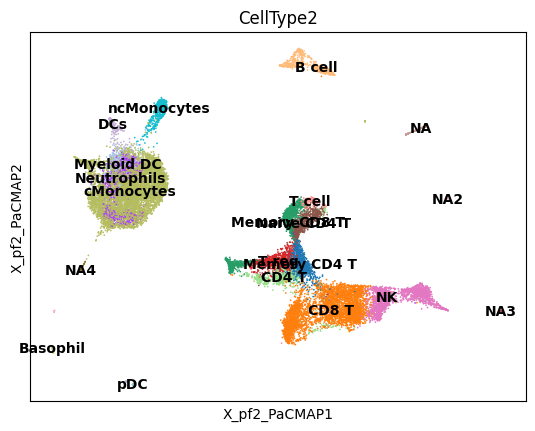

AttributeError: 'DataFrame' object has no attribute 'leiden'

In [9]:
adata.obs["CellType2"] = adata.obs.leiden.replace(celltypedict_layer2)
sc.pl.embedding(basis="X_pf2_PaCMAP", adata=adata, color=["CellType2"], legend_loc='on data') #basis of cell embedding  use projections form pf2
data.obs["CellType2"] = data.obs.leiden.replace(celltypedict_layer2)

In [71]:
data.write_h5ad("Cytokine_Pf2_annotated_NB_031725.h5ad")

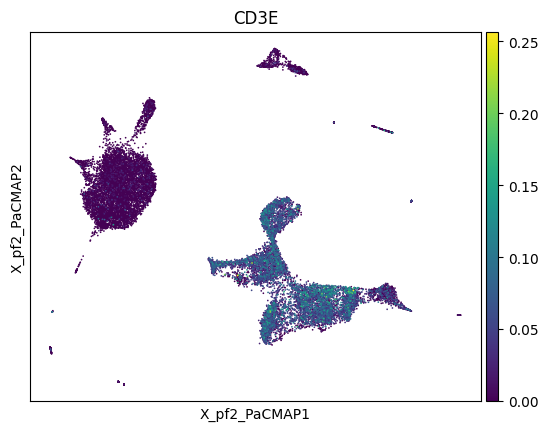

In [60]:
sc.pl.embedding(data, basis="X_pf2_PaCMAP", color=["CD3E"])

## PF2 PACMAPs

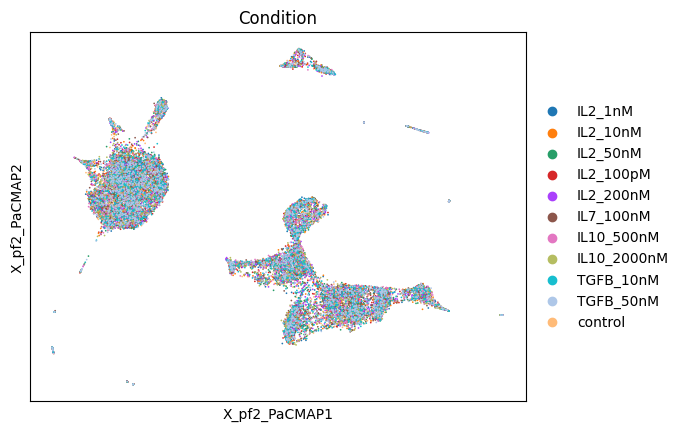

In [38]:
sc.pl.embedding(data, basis="X_pf2_PaCMAP", color=["Condition"])

/home/brianoj/.cache/pypoetry/virtualenvs/sccp-rvA4szVo-py3.11/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/brianoj/.cache/pypoetry/virtualenvs/sccp-rvA4szVo-py3.11/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


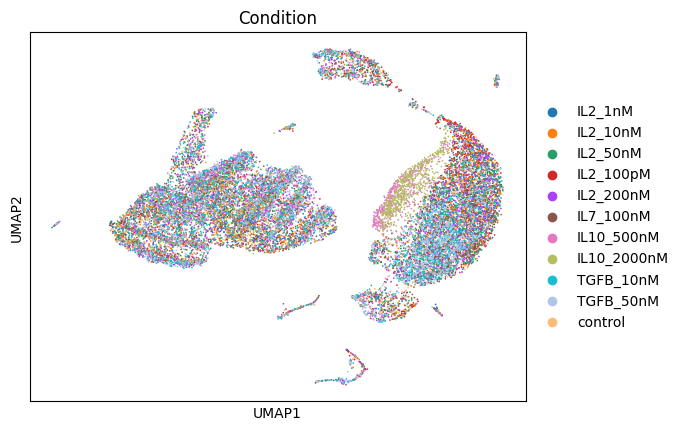

In [10]:
sc.pl.umap(data, color=["Condition"],)